# Hiperparametrizacion para Clasificación: Predicción de salida del cliente del banco

1. Preparación de Datos
2. División de los Datos
3. Hiperparametrización con el 70%
4. Evaluación del mejor Modelo con el 30%
5. Guardar el Modelo

Imagen de ejemplificación sobre la Hiperparametrización. Tomado del notebook 2. Hiperparametrizacion_Clasificacion_Calidad_Aire.ipynb en posesión de la docente Ana Isabel Oviedo


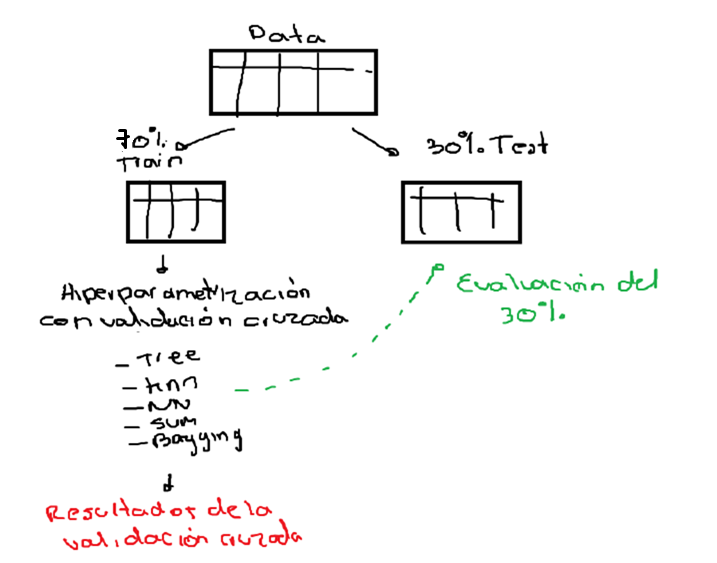

In [17]:
#Cargamos librerías principales
import pandas as pd # manipulacion dataframes
import numpy as np  # matrices y vectores
import matplotlib.pyplot as plt #gráfica

# 1. Preparación de Datos

In [18]:
#Cargamos los datos preparados, resultado de notebook 1.calidad_datos.ipynb
data = pd.read_excel("datos_P_Churn_Modelling.xlsx")
data.head()

,Unnamed: 0,Geography,Gender,Age,Balance,NumOfProducts,IsActiveMember,Exited
0,0,France,Female,42.0,0.00,1,Si,Si
1,1,Spain,Female,41.0,83807.86,1,Si,No
2,2,France,Female,42.0,159660.80,3,No,Si
3,3,France,Female,39.0,0.00,2,No,No
4,4,Spain,Female,43.0,125510.82,1,Si,No


In [19]:
#Conocemos los datos
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15920 entries, 0 to 15919
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      15920 non-null  int64  
 1   Geography       15920 non-null  object 
 2   Gender          15920 non-null  object 
 3   Age             15920 non-null  float64
 4   Balance         15920 non-null  float64
 5   NumOfProducts   15920 non-null  int64  
 6   IsActiveMember  15920 non-null  object 
 7   Exited          15920 non-null  object 
dtypes: float64(2), int64(2), object(4)
memory usage: 995.1+ KB


In [20]:
#Corrección de variables categóricas
data['Geography'] = data['Geography'].astype('category')
data['Gender'] = data['Gender'].astype('category')
data['NumOfProducts'] = data['NumOfProducts'].astype('category')
data['IsActiveMember'] = data['IsActiveMember'].astype('category')
data['Exited'] = data['Exited'].astype('category')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15920 entries, 0 to 15919
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   Unnamed: 0      15920 non-null  int64   
 1   Geography       15920 non-null  category
 2   Gender          15920 non-null  category
 3   Age             15920 non-null  float64 
 4   Balance         15920 non-null  float64 
 5   NumOfProducts   15920 non-null  category
 6   IsActiveMember  15920 non-null  category
 7   Exited          15920 non-null  category
dtypes: category(5), float64(2), int64(1)
memory usage: 451.7 KB


In [21]:
data.head()

,Unnamed: 0,Geography,Gender,Age,Balance,NumOfProducts,IsActiveMember,Exited
0,0,France,Female,42.0,0.00,1,Si,Si
1,1,Spain,Female,41.0,83807.86,1,Si,No
2,2,France,Female,42.0,159660.80,3,No,Si
3,3,France,Female,39.0,0.00,2,No,No
4,4,Spain,Female,43.0,125510.82,1,Si,No


In [22]:
# Eliminar variable Unnamed:0 (IRRELEVANTE)
data = data.drop('Unnamed: 0',axis=1) #Eaxis=1 indica que es una columna
data.head()

,Geography,Gender,Age,Balance,NumOfProducts,IsActiveMember,Exited
0,France,Female,42.0,0.00,1,Si,Si
1,Spain,Female,41.0,83807.86,1,Si,No
2,France,Female,42.0,159660.80,3,No,Si
3,France,Female,39.0,0.00,2,No,No
4,Spain,Female,43.0,125510.82,1,Si,No


<Axes: >

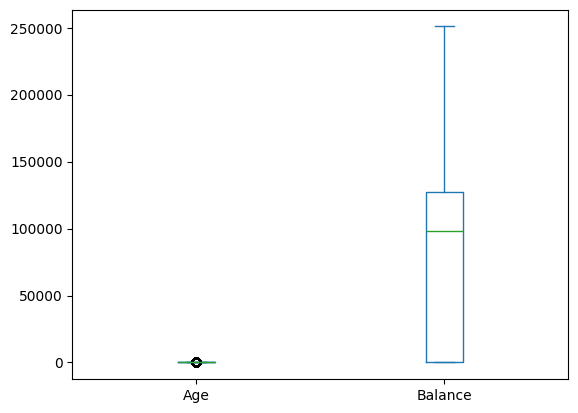

In [23]:
#Descripción variables numérica
data.plot(kind='box')

<Axes: xlabel='Geography'>

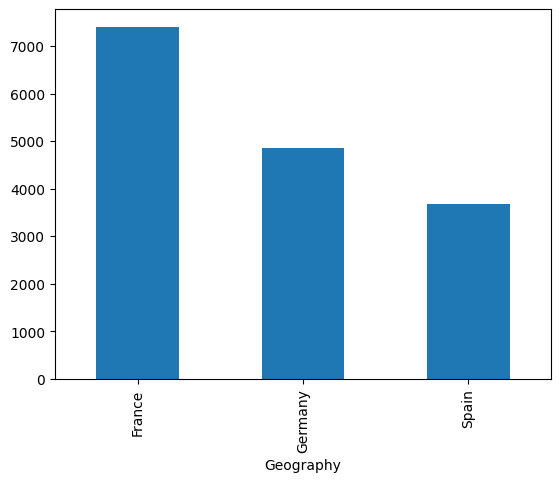

In [24]:
#Descripción variables categóricas
data['Geography'].value_counts().plot(kind='bar')

<Axes: xlabel='Gender'>

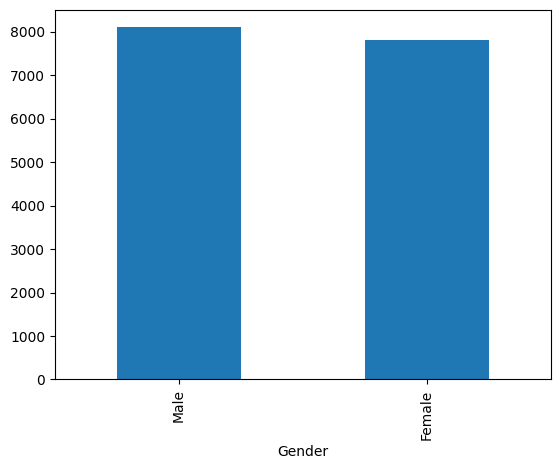

In [25]:
#Descripción variables categóricas
data['Gender'].value_counts().plot(kind='bar')

<Axes: xlabel='NumOfProducts'>

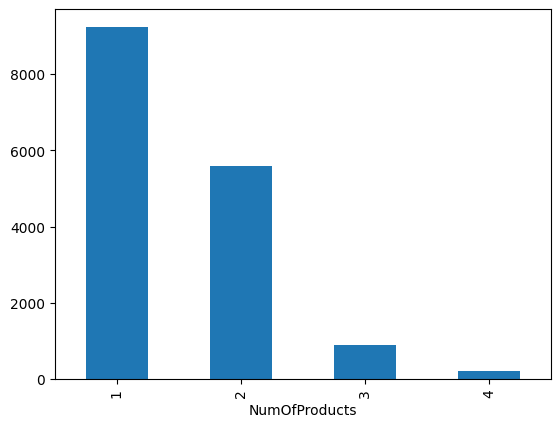

In [26]:
#Descripción variables categóricas
data['NumOfProducts'].value_counts().plot(kind='bar')

<Axes: xlabel='IsActiveMember'>

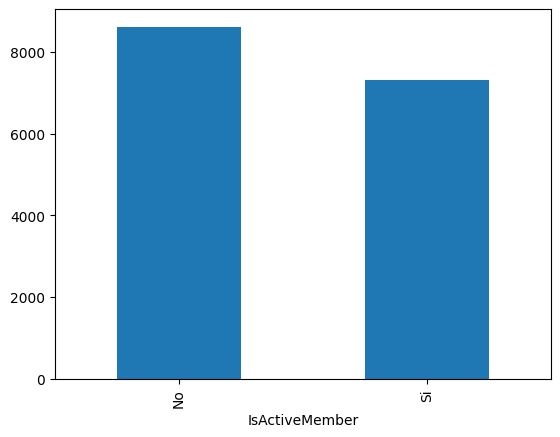

In [27]:
#Descripción variables categóricas
data['IsActiveMember'].value_counts().plot(kind='bar')

<Axes: xlabel='Exited'>

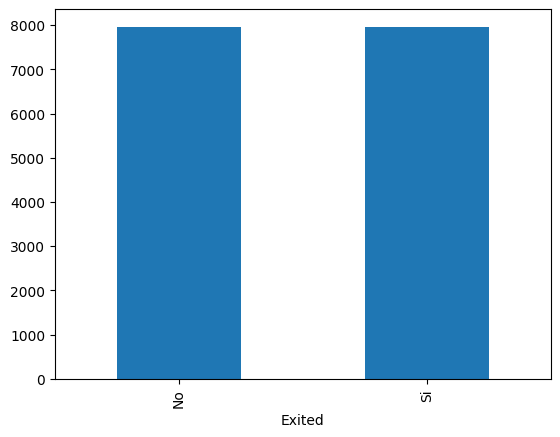

In [28]:
#Descripción variables categóricas
data['Exited'].value_counts().plot(kind='bar') #Variable Objetivo

<Axes: ylabel='count'>

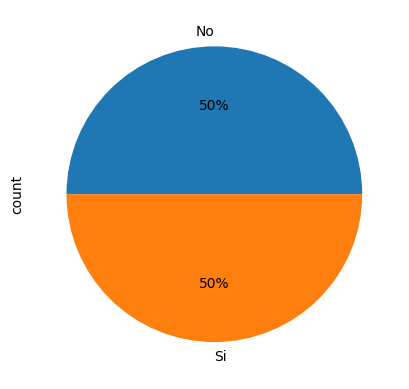

In [29]:
data['Exited'].value_counts().plot(kind='pie', autopct='%.0f%%')

In [30]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15920 entries, 0 to 15919
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   Geography       15920 non-null  category
 1   Gender          15920 non-null  category
 2   Age             15920 non-null  float64 
 3   Balance         15920 non-null  float64 
 4   NumOfProducts   15920 non-null  category
 5   IsActiveMember  15920 non-null  category
 6   Exited          15920 non-null  category
dtypes: category(5), float64(2)
memory usage: 327.3 KB


In [31]:
#Se crean dummies a las variables predictoras categóricas (no a la variable obj)
data = pd.get_dummies(data, columns=['Geography', 'NumOfProducts'], drop_first=False, dtype=int)
data = pd.get_dummies(data, columns=['Gender', 'IsActiveMember'], drop_first=True, dtype=int)
data.head()

,Age,Balance,Exited,Geography_France,Geography_Germany,Geography_Spain,NumOfProducts_1,NumOfProducts_2,NumOfProducts_3,NumOfProducts_4,Gender_Male,IsActiveMember_Si
0,42.0,0.00,Si,1,0,0,1,0,0,0,0,1
1,41.0,83807.86,No,0,0,1,1,0,0,0,0,1
2,42.0,159660.80,Si,1,0,0,0,0,1,0,0,0
3,39.0,0.00,No,1,0,0,0,1,0,0,0,0
4,43.0,125510.82,No,0,0,1,1,0,0,0,0,1


In [32]:
#Se codifican las categorias de la VARIABLE OBJETIVO LABELENCODE (Cambiar No y Si por 0 y 1)

from sklearn.preprocessing import LabelEncoder
labelencoder = LabelEncoder()
data["Exited"]=labelencoder.fit_transform(data["Exited"]) #Objetivo

data.head()

,Age,Balance,Exited,Geography_France,Geography_Germany,Geography_Spain,NumOfProducts_1,NumOfProducts_2,NumOfProducts_3,NumOfProducts_4,Gender_Male,IsActiveMember_Si
0,42.0,0.00,1,1,0,0,1,0,0,0,0,1
1,41.0,83807.86,0,0,0,1,1,0,0,0,0,1
2,42.0,159660.80,1,1,0,0,0,0,1,0,0,0
3,39.0,0.00,0,1,0,0,0,1,0,0,0,0
4,43.0,125510.82,0,0,0,1,1,0,0,0,0,1


# 2. División 70-30

<Axes: xlabel='Exited'>

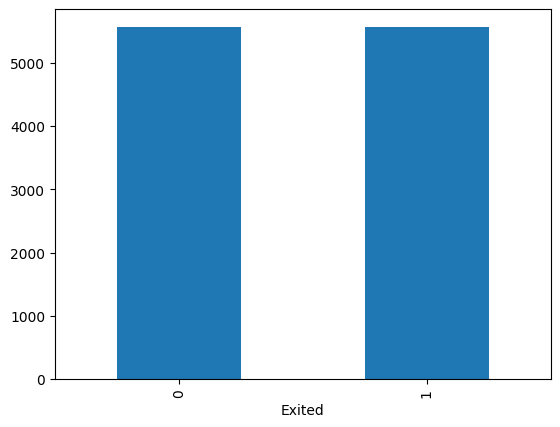

In [33]:
#División 70-30
from sklearn.model_selection import train_test_split
X = data.drop("Exited", axis = 1) # Variables predictoras
Y = data['Exited'] #Variable objetivo
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, stratify=Y) #Muestreo estratificado (cuando la variable es una categoria (solo aca), me siga el mismo patron de cantidad tanto en test como en train)
Y_train.value_counts().plot(kind='bar')

<Axes: xlabel='Exited'>

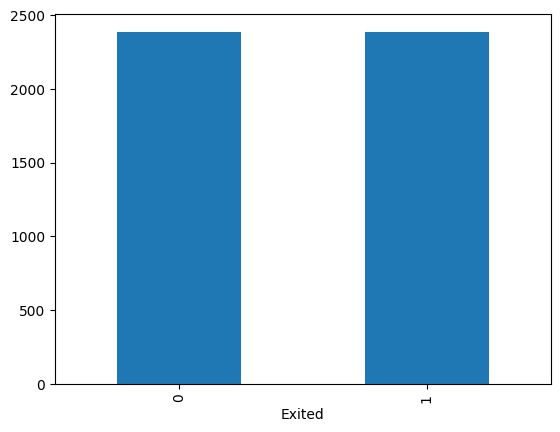

In [34]:
#Variable objetivo del 30%
Y_test.value_counts().plot(kind='bar')

# 3. Hiperparametrización con el 70%

In [35]:
#Medida de evaluación del mejor modelo
medidas= pd.DataFrame(index=['f1 de la CV'])

# **Hiperparametrización Arbol de Clasificación**

En el apartado de Minería de Datos, Notebook *2.Mineria_Datos.ipynb* concluimos que el modelo con el mejor desempeño de acuerdo con la medida AUC fue el Random Forest. Debido, a que la Hiperparametrización recrea múltiples modelos en su ejecución, por temas de recursos y eficiencia se descarta la posibilidad de realizar Hiperparametrización con **Random Forest**. Como segunda elección por medida de calidad AUC, se elige el modelo de **árbol de Decisión** para realizar la Hiperparametrización.

In [36]:
#  Arbol
from sklearn.tree import DecisionTreeClassifier
modelTree = DecisionTreeClassifier() # Instanciar parametrizacion

# Definir los hiperparametros
criterion=['entropy','gini'] #Indice de información
min_samples_leaf=[2,10,50,100] # Cantidad de registros por hoja
max_depth=[None, 10,20,50] #Niveles de profundidad


In [38]:
#Hiperparametrización
from sklearn.model_selection import GridSearchCV

param_grid = dict(criterion=criterion, min_samples_leaf=min_samples_leaf, max_depth=max_depth) # Configurar Diccionario
grid = GridSearchCV(estimator=modelTree, param_grid=param_grid, scoring='f1_macro', n_jobs=-1, cv=10) #cv=10 grupos de validación cruzada, deberia ser en 10, siempre
grid.fit(X_train, Y_train) #70%

#Mejor modelo
modelTree= grid.best_estimator_


medidas['Tree']=grid.best_score_ #guarda la calidad del mejor de los modelos

# Mejores párametros
print( grid.best_params_)
print(medidas)

{'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 2}
                 Tree
f1 de la CV  0.843936


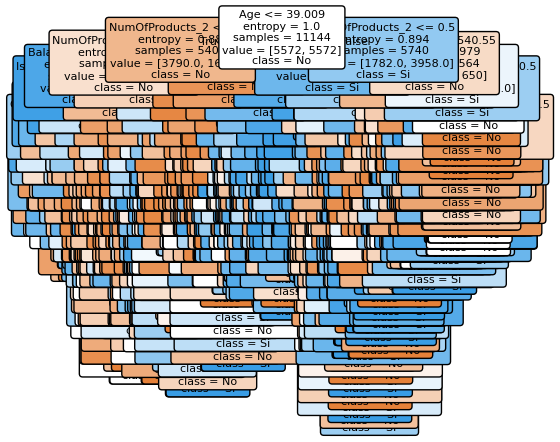

In [39]:
#Mejor modelo
from sklearn.tree import plot_tree
plt.figure(figsize=(5,5))
plot_tree(modelTree, feature_names=X_train.columns.values, class_names=labelencoder.classes_, rounded=True, filled=True, fontsize=8)
plt.show()

# 4. Evaluación de los mejores modelos con el 30%

              precision    recall  f1-score   support

          No       0.85      0.87      0.86      2388
          Si       0.86      0.85      0.86      2388

    accuracy                           0.86      4776
   macro avg       0.86      0.86      0.86      4776
weighted avg       0.86      0.86      0.86      4776



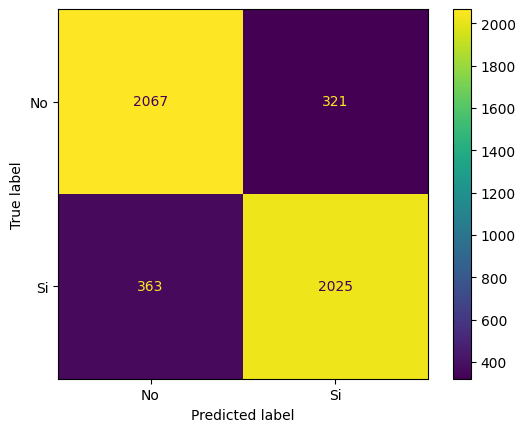

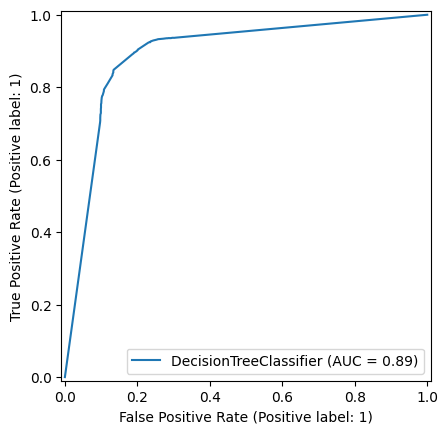

In [40]:
#Evaluación del mejor Tree con el 30% (X_test sin normalizar)
from sklearn import metrics

Y_pred = modelTree.predict(X_test) #30%

#Matriz de confusion
cm=metrics.confusion_matrix(y_true=Y_test, y_pred=Y_pred)
disp=metrics.ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=labelencoder.classes_)
disp.plot()

#Precision, Recall, f1, exactitud
print(metrics.classification_report( y_true=Y_test, y_pred=Y_pred, target_names=labelencoder.classes_))

# Curva ROC
metrics.RocCurveDisplay.from_estimator(modelTree,X_test, Y_test)

# 4. Guardamos el modelo

In [41]:
import pickle
filename = 'modeloTree-clas-hiper.pkl'
variables= X.columns._values
pickle.dump([modelTree,labelencoder,variables], open(filename, 'wb')) #write
